# 도메인별 모델 성능 평가 — F1 Score

**평가 방식**: `logs/final_detection_results/` 의 타임시리즈 CSV 를 로드해  
라벨 이벤트 구간을 ground-truth 로 삼아 F1 / Precision / Recall / Confusion Matrix 를 계산합니다.

- **3단 임계값**: Caution(`alarm_level≥1`) · Warning(`≥2`) · Critical(`≥3`)
- **PR-Curve**: MSE 를 직접 스코어로 사용해 임계값 sweep
- **이벤트 레벨 F1**: 분 단위가 아닌 이벤트 단위 (hit=TP, miss=FN)

In [36]:
# ── 라이브러리 임포트 ─────────────────────────────────────────────────────
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# sklearn 평가 지표: F1, Precision, Recall, Confusion Matrix, PR-Curve, Average Precision
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)

# ── Matplotlib 한글 출력 설정 ─────────────────────────────────────────────
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트
plt.rcParams["axes.unicode_minus"] = False      # 마이너스(-) 기호 깨짐 방지

In [37]:
# MACOS 한글 폰트 설정 (필요 시)
# import platform

In [38]:
# ── 경로 설정 ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT  = NOTEBOOK_DIR                        # eval_f1.ipynb 는 models/ 루트에 위치
RESULTS_DIR   = os.path.join(PROJECT_ROOT, "logs", "final_detection_results")  # 추론 결과 CSV 들이 저장된 폴더

# ── 평가 대상 도메인 자동 수집 ────────────────────────────────────────────
# RESULTS_DIR 안의 "*_timeseries.csv" 파일명에서 도메인명만 추출해 정렬
DOMAINS = sorted({
    f.replace("_timeseries.csv", "")
    for f in os.listdir(RESULTS_DIR)
    if f.endswith("_timeseries.csv")
})
print("평가 도메인:", DOMAINS)

평가 도메인: ['hydraulic', 'motor', 'nutrient', 'zone_drip']


In [39]:
# ── 라벨 이벤트 정의 (train.py 와 동일하게 유지) ──────────────────────────
# 실제 이상이 발생한 것으로 라벨링된 5개의 기간.
# 이 구간을 ground-truth(정답) 로 삼아 예측값과 비교한다.
LABELED_EVENTS = [
    ("2026-04-01 00:00:00", "2026-04-07 23:59:59"),
    ("2026-04-14 00:00:00", "2026-04-20 23:59:59"),
    ("2026-04-25 00:00:00", "2026-05-05 23:59:59"),
    ("2026-05-10 00:00:00", "2026-05-20 23:59:59"),
    ("2026-05-21 00:00:00", "2026-05-29 23:59:59"),
]

def make_ground_truth(index: pd.DatetimeIndex, events=LABELED_EVENTS) -> np.ndarray:
    """타임스탬프 인덱스를 이진 라벨로 변환.
    이벤트 구간에 해당하면 1(이상), 아니면 0(정상).
    """
    y = np.zeros(len(index), dtype=int)             # 기본값 0(정상)으로 초기화
    for s, e in events:
        # 이벤트 시작~끝 사이의 타임스탬프를 찾아 1(이상)로 마킹
        mask = (index >= pd.to_datetime(s)) & (index <= pd.to_datetime(e))
        y[mask] = 1
    return y

In [40]:
# ── 데이터 로드 ───────────────────────────────────────────────────────────
# 각 도메인별로 2개 파일 로드:
#   - {dom}_timeseries.csv : 분 단위 추론 결과 (timestamp, alarm_level, current_mse 등)
#   - {dom}_event_detail.csv : 탐지된 개별 이벤트 상세 정보
domain_data = {}
for dom in DOMAINS:
    ts_path  = os.path.join(RESULTS_DIR, f"{dom}_timeseries.csv")
    evt_path = os.path.join(RESULTS_DIR, f"{dom}_event_detail.csv")

    # timestamp 를 인덱스로 사용해 DatetimeIndex 형태의 DataFrame 생성
    df = pd.read_csv(ts_path, parse_dates=["timestamp"], index_col="timestamp")
    df["y_true"] = make_ground_truth(df.index)     # 라벨 컬럼 추가

    evt_df = pd.read_csv(evt_path)
    domain_data[dom] = {"ts": df, "events": evt_df}

# ── 로드 결과 요약 출력 ───────────────────────────────────────────────────
print("로드 완료")
for dom, d in domain_data.items():
    df = d["ts"]
    pos = df["y_true"].sum()                        # 이상(=1)으로 마킹된 행 수
    print(f"  {dom:12s}: 전체 {len(df):,}행 | 이상(=1) {pos:,}행 ({pos/len(df)*100:.1f}%)")

로드 완료
  hydraulic   : 전체 84,950행 | 이상(=1) 64,790행 (76.3%)
  motor       : 전체 84,950행 | 이상(=1) 64,790행 (76.3%)
  nutrient    : 전체 84,950행 | 이상(=1) 64,790행 (76.3%)
  zone_drip   : 전체 84,950행 | 이상(=1) 64,790행 (76.3%)


---
## 1. 임계값 레벨별 F1 / Precision / Recall

In [41]:
def threshold_metrics(y_true, alarm_level, level: int):
    """특정 임계값 레벨(1:Caution, 2:Warning, 3:Critical)에서 분류 성능 지표를 계산.

    Args:
        y_true      : (N,) 실제 라벨 (0=정상, 1=이상)
        alarm_level : (N,) 모델이 산출한 경보 단계 (0~3)
        level       : 예측을 양성(이상)으로 간주할 기준 레벨

    Returns:
        dict: TP/FP/TN/FN 개수와 Precision/Recall/F1 (소수점 4자리)
    """
    y_pred = (alarm_level >= level).astype(int)     # level 이상이면 이상으로 예측

    # ── Confusion Matrix 원소 직접 계산 ───────────────────────────────────
    tp = int(((y_pred == 1) & (y_true == 1)).sum())  # 이상을 이상으로 맞춤
    fp = int(((y_pred == 1) & (y_true == 0)).sum())  # 정상을 이상으로 오탐
    tn = int(((y_pred == 0) & (y_true == 0)).sum())  # 정상을 정상으로 맞춤
    fn = int(((y_pred == 0) & (y_true == 1)).sum())  # 이상을 정상으로 놓침

    # zero_division=0 : 분모 0일 때 경고 없이 0으로 반환
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return dict(TP=tp, FP=fp, TN=tn, FN=fn,
                Precision=round(p,4), Recall=round(r,4), F1=round(f1,4))

# 임계값 레벨 번호 → 이름 매핑
LEVEL_NAMES = {1: "Caution", 2: "Warning", 3: "Critical"}

# ── 모든 (도메인 × 임계값) 조합에 대해 지표 계산 ─────────────────────────
rows = []
for dom, d in domain_data.items():
    df = d["ts"]
    y_true      = df["y_true"].values
    alarm_level = df["alarm_level"].values
    for lv, name in LEVEL_NAMES.items():
        m = threshold_metrics(y_true, alarm_level, lv)
        rows.append({"Domain": dom, "Threshold": name, **m})

metric_df = pd.DataFrame(rows)
metric_df

,Domain,Threshold,TP,FP,TN,FN,Precision,Recall,F1
0,hydraulic,Caution,63935,20160,0,855,0.7603,0.9868,0.8589
1,hydraulic,Warning,62854,20160,0,1936,0.7571,0.9701,0.8505
2,hydraulic,Critical,61459,20160,0,3331,0.7530,0.9486,0.8396
3,motor,Caution,55787,18845,1315,9003,0.7475,0.8610,0.8003
4,motor,Warning,54944,16345,3815,9846,0.7707,0.8480,0.8075
5,motor,Critical,54399,13971,6189,10391,0.7957,0.8396,0.8170
6,nutrient,Caution,64708,20160,0,82,0.7625,0.9987,0.8647
7,nutrient,Warning,64220,20160,0,570,0.7611,0.9912,0.8610
8,nutrient,Critical,63343,20160,0,1447,0.7586,0.9777,0.8543
9,zone_drip,Caution,58728,18763,1397,6062,0.7579,0.9064,0.8255


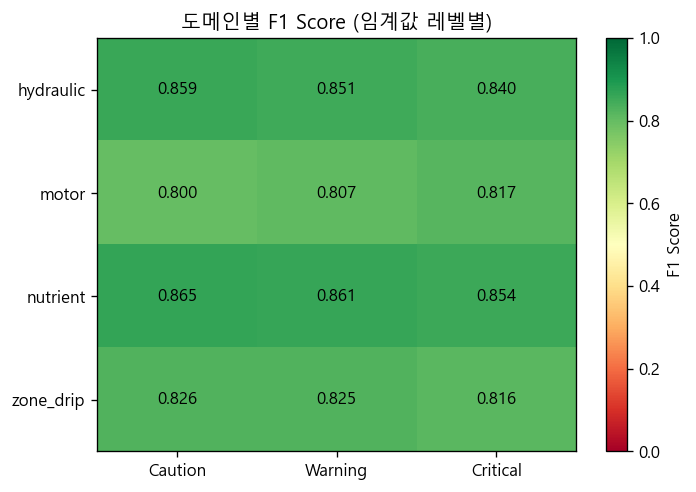

In [42]:
# ── F1 히트맵: 도메인(행) × 임계값(열) ───────────────────────────────────
# pivot: long-format DataFrame 을 wide-format 매트릭스로 변환
pivot = metric_df.pivot(index="Domain", columns="Threshold", values="F1")[["Caution","Warning","Critical"]]

fig, ax = plt.subplots(figsize=(6, len(DOMAINS) * 0.8 + 1))
# RdYlGn 컬러맵: 0(빨강) → 0.5(노랑) → 1(초록)
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="F1 Score")

# 축 라벨 설정
ax.set_xticks(range(3)); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index)

# 각 셀 위에 F1 값을 텍스트로 표시
for i in range(len(pivot)):
    for j in range(3):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center", fontsize=10)
ax.set_title("도메인별 F1 Score (임계값 레벨별)")
plt.tight_layout()
plt.show()

---
## 2. 도메인별 Confusion Matrix

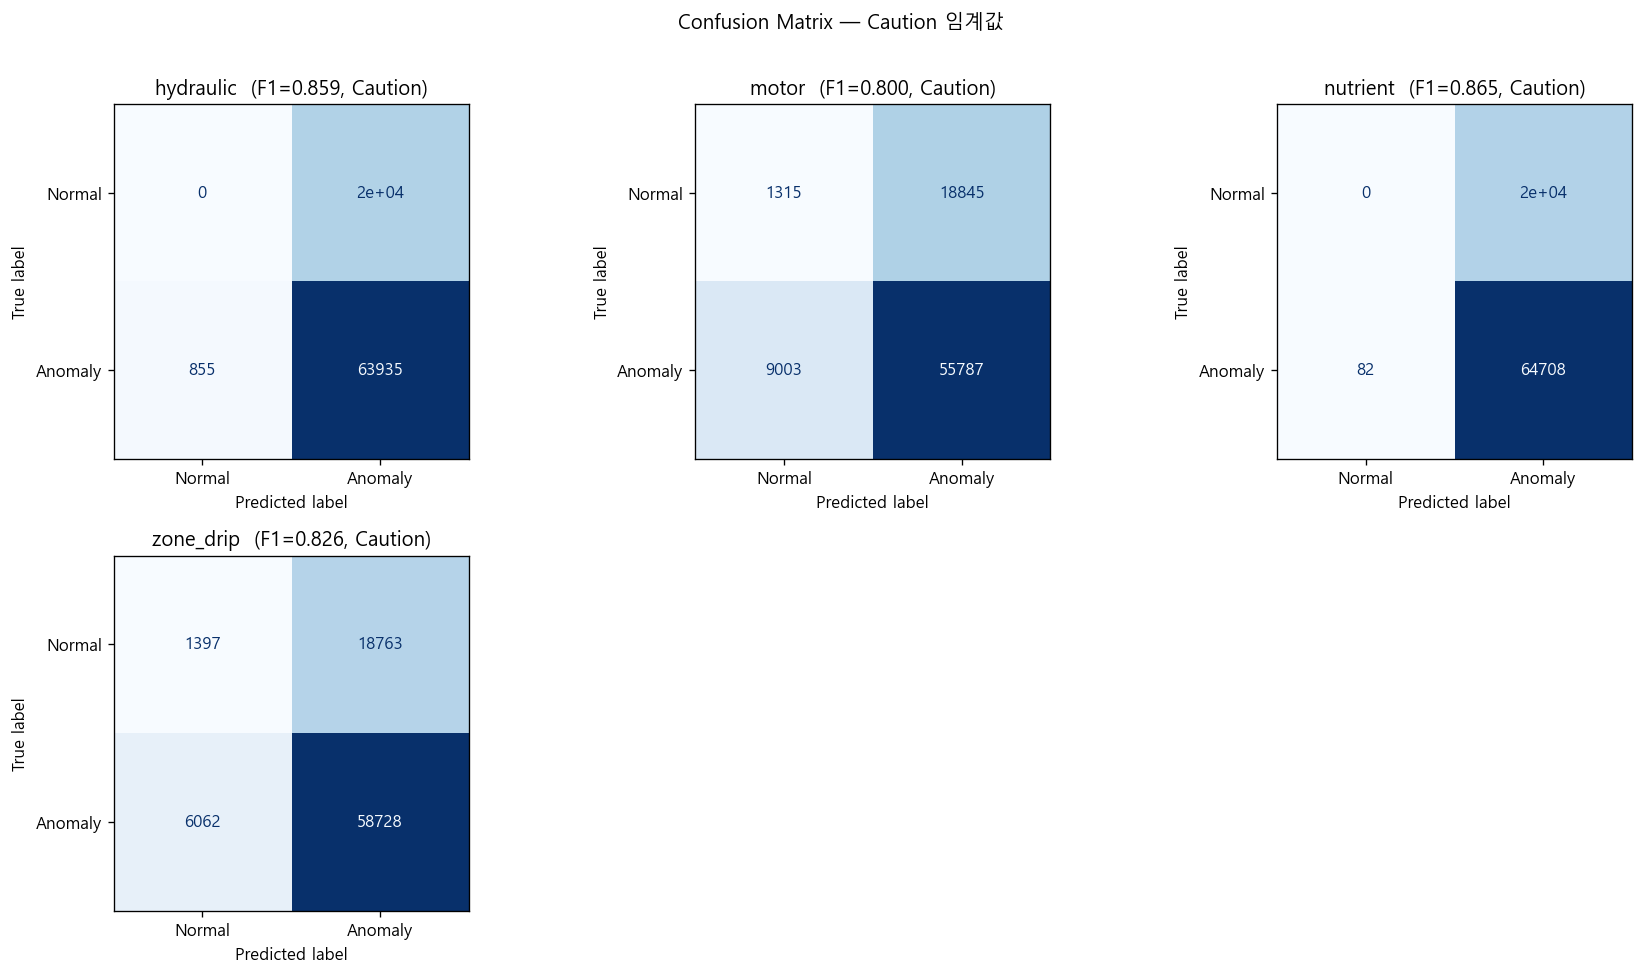

In [43]:
EVAL_LEVEL = 1   # ← Caution(1) / Warning(2) / Critical(3) 중 원하는 레벨로 변경

# ── 서브플롯 그리드 크기 계산 (최대 3열 고정) ─────────────────────────────
n = len(DOMAINS)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols                    # 올림 나눗셈으로 필요한 행 수
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()                     # 1D 배열로 변환해 인덱싱 단순화

# ── 각 도메인별 Confusion Matrix 그리기 ───────────────────────────────────
for i, dom in enumerate(DOMAINS):
    df = domain_data[dom]["ts"]
    y_true = df["y_true"].values
    y_pred = (df["alarm_level"].values >= EVAL_LEVEL).astype(int)  # EVAL_LEVEL 기준 이진화

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")

    # 제목에 F1 점수와 임계값 이름을 함께 표시
    f1 = f1_score(y_true, y_pred, zero_division=0)
    axes[i].set_title(f"{dom}  (F1={f1:.3f}, {LEVEL_NAMES[EVAL_LEVEL]})")

# 도메인 수가 grid 보다 적을 경우, 남는 축은 숨김 처리
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f"Confusion Matrix — {LEVEL_NAMES[EVAL_LEVEL]} 임계값", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Precision-Recall Curve (MSE 직접 스윕)

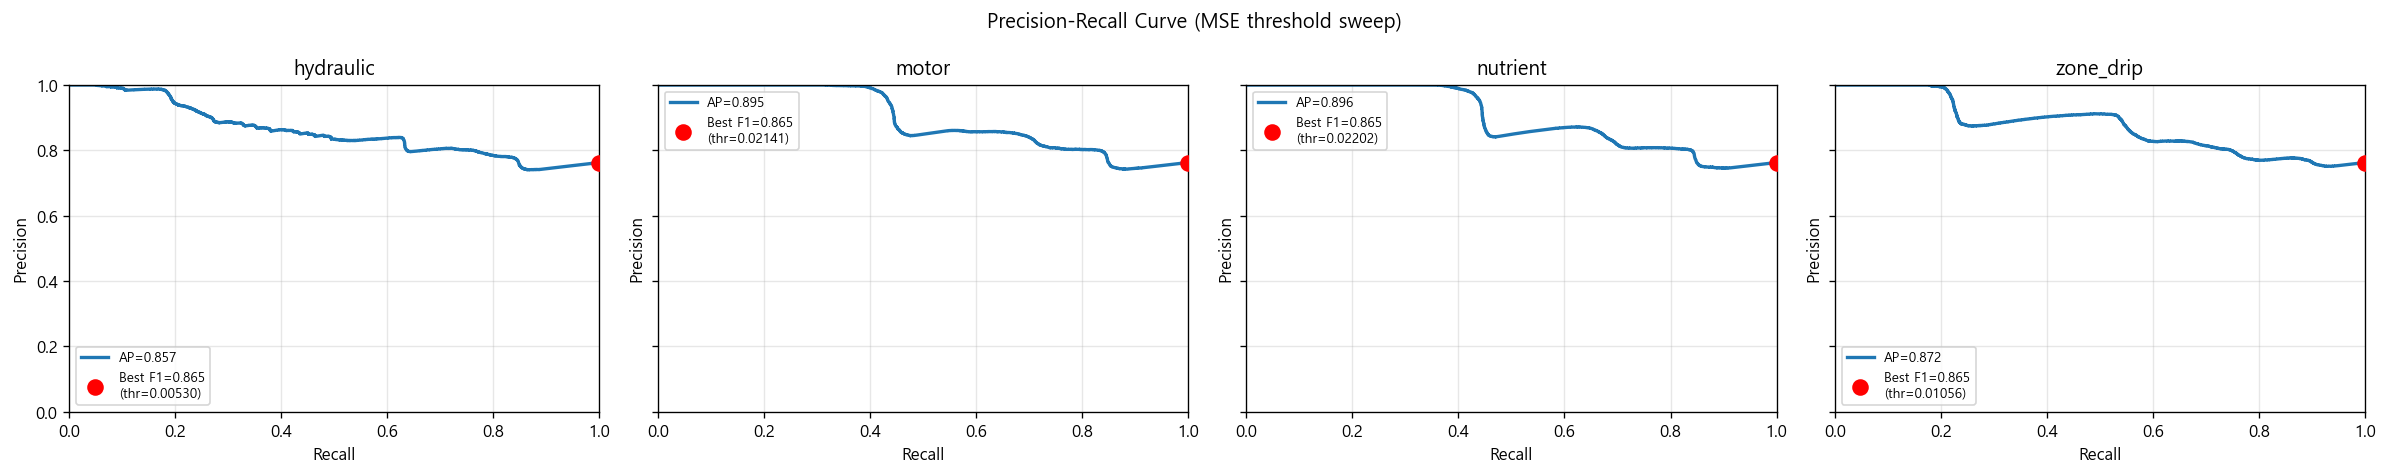

In [44]:
# ── PR-Curve: 도메인별 서브플롯 구성 ──────────────────────────────────────
fig, axes = plt.subplots(1, len(DOMAINS), figsize=(5 * len(DOMAINS), 4), sharey=True)
if len(DOMAINS) == 1:
    axes = [axes]                                   # 도메인 1개일 때도 반복 가능하도록 리스트화

for ax, dom in zip(axes, DOMAINS):
    df = domain_data[dom]["ts"]
    y_true = df["y_true"].values
    scores = df["current_mse"].values               # MSE: 값이 클수록 이상일 가능성↑

    # ── 임계값을 쓸어가며 Precision/Recall 계산 ──────────────────────────
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)    # PR-Curve 아래 면적 (Average Precision)

    # ── F1 이 최대가 되는 지점 탐색 ──────────────────────────────────────
    # 분모 0 방지: (precision+recall)==0 인 지점은 F1=0 으로 처리
    f1_vals = np.where((precision + recall) == 0, 0,
                       2 * precision * recall / (precision + recall + 1e-12))
    best_idx = np.argmax(f1_vals[:-1])              # precision_recall_curve 마지막 원소(=1,0)는 제외
    best_f1  = f1_vals[best_idx]
    best_thr = thresholds[best_idx]

    # ── PR-Curve 본체와 최적 F1 지점(빨간 점) 표시 ───────────────────────
    ax.plot(recall, precision, lw=2, label=f"AP={ap:.3f}")
    ax.scatter(recall[best_idx], precision[best_idx],
               color="red", zorder=5, s=80,
               label=f"Best F1={best_f1:.3f}\n(thr={best_thr:.5f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(dom)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle("Precision-Recall Curve (MSE threshold sweep)")
plt.tight_layout()
plt.show()

---
## 4. 이벤트 레벨 F1

분 단위가 아닌 **이벤트 5개를 단위**로 hit/miss/FP 를 집계합니다.  
- 이벤트 기간 내에 알람이 1번이라도 울리면 → **TP** (hit or late 모두 포함)  
- 이벤트 기간 내 알람 없음 → **FN** (miss)  
- 정상 구간에서 알람이 울린 분 수 → FP 기여 (이벤트 외 알람 있으면 FP=1 카운트)

In [45]:
def event_level_f1(ts_df, events=LABELED_EVENTS, alarm_col="pred_is_anomaly"):
    """이벤트 단위로 TP/FP/FN 을 집계해 F1 을 계산.

    분(minute) 단위가 아닌 "이벤트 5개" 를 평가 단위로 본다.
        - 이벤트 구간 내 알람 1회 이상 발생 → TP (hit)
        - 이벤트 구간 내 알람 0회           → FN (miss)
        - 정상 구간에서 알람 1회라도 발생   → FP 슬롯 1 카운트 (bool 개념)
        - 또한 FP 의 분 단위 개수(FP_minutes)도 함께 반환
    """
    tp = fp = fn = 0
    # 문자열 이벤트 구간 → Timestamp 튜플 리스트로 사전 변환 (반복 호출 방지)
    event_ranges = [(pd.to_datetime(s), pd.to_datetime(e)) for s, e in events]

    # ── 이벤트 구간별 TP / FN 판정 ────────────────────────────────────────
    for s, e in event_ranges:
        ev_slice = ts_df.loc[(ts_df.index >= s) & (ts_df.index <= e)]
        if ev_slice[alarm_col].sum() > 0:           # 구간 내 알람이 한 번이라도 있으면
            tp += 1                                 # → 이벤트 감지 성공
        else:
            fn += 1                                 # → 이벤트 놓침

    # ── 정상 구간(이벤트 밖) 마스크 생성 ──────────────────────────────────
    normal_mask = np.ones(len(ts_df), dtype=bool)
    for s, e in event_ranges:
        # 이벤트 구간을 하나씩 AND-NOT 으로 제거
        normal_mask &= ~((ts_df.index >= s) & (ts_df.index <= e))

    # 정상 구간에서 울린 알람의 분(minute) 수 = 오탐의 세밀한 개수
    fp_minutes = int(ts_df.loc[normal_mask, alarm_col].sum())
    # 이벤트-슬롯 단위 FP: "정상 구간에서 알람이 한 번이라도 있었는가" 만 본다
    fp = 1 if fp_minutes > 0 else 0

    # ── 최종 지표 계산 (분모 0 방지) ──────────────────────────────────────
    p  = tp / (tp + fp) if (tp + fp) else 0.0
    r  = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2*p*r / (p+r) if (p+r) else 0.0
    return dict(TP=tp, FP_slots=fp, FP_minutes=fp_minutes, FN=fn,
                Precision=round(p,4), Recall=round(r,4), F1=round(f1,4))

# ── 도메인별로 이벤트 레벨 F1 수집 ────────────────────────────────────────
evt_rows = []
for dom, d in domain_data.items():
    r = event_level_f1(d["ts"])
    evt_rows.append({"Domain": dom, **r})

evt_df = pd.DataFrame(evt_rows).set_index("Domain")
evt_df

,TP,FP_slots,FP_minutes,FN,Precision,Recall,F1
Domain,,,,,,,
hydraulic,5,1,20160,0,0.8333,1.0,0.9091
motor,5,1,18845,0,0.8333,1.0,0.9091
nutrient,5,1,20160,0,0.8333,1.0,0.9091
zone_drip,5,1,18763,0,0.8333,1.0,0.9091


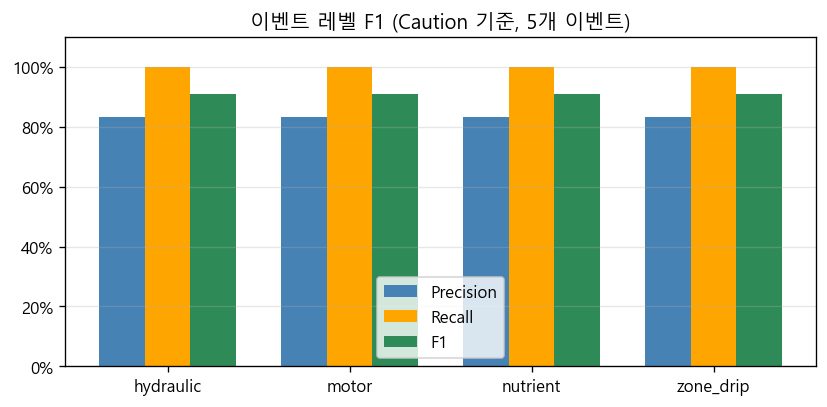

In [46]:
# ── 이벤트 레벨 F1 바 차트 ────────────────────────────────────────────────
# 도메인별로 Precision / Recall / F1 를 나란히 비교
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(DOMAINS))                         # 도메인별 x축 위치
w = 0.25                                            # 막대 너비 (3개 겹치지 않게)

# 각 지표를 살짝 어긋나게 배치하여 그룹 바 차트 형태로 표시
ax.bar(x - w, evt_df["Precision"], w, label="Precision", color="steelblue")
ax.bar(x,     evt_df["Recall"],    w, label="Recall",    color="orange")
ax.bar(x + w, evt_df["F1"],        w, label="F1",        color="seagreen")

ax.set_xticks(x); ax.set_xticklabels(DOMAINS)
ax.set_ylim(0, 1.1)
# y축을 % 포맷으로 (0.8 → 80%)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("이벤트 레벨 F1 (Caution 기준, 5개 이벤트)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. 전체 요약 테이블

In [47]:
# ── 전체 요약 테이블: 한 도메인 = 한 행 ───────────────────────────────────
# 각 도메인별로 아래 지표들을 한 행에 모아서 최종 비교 테이블을 만든다.
#   - F1_Caution / F1_Warning / F1_Critical : 임계값 레벨별 F1
#   - AP (PR-AUC)                           : MSE 기반 PR-Curve 면적
#   - Event_F1                              : 이벤트 단위 F1
#   - FP_minutes                            : 정상 구간 오탐 분 수 (참고용)
summary_rows = []
for dom, d in domain_data.items():
    df   = d["ts"]
    y_t  = df["y_true"].values
    alv  = df["alarm_level"].values
    mse  = df["current_mse"].values

    row = {"Domain": dom}

    # ── (1) 임계값 레벨별 F1 ──────────────────────────────────────────────
    for lv, name in LEVEL_NAMES.items():
        m = threshold_metrics(y_t, alv, lv)
        row[f"F1_{name}"] = m["F1"]

    # ── (2) MSE 직접 스윕 기반 Average Precision ──────────────────────────
    ap = average_precision_score(y_t, mse)
    row["AP (PR-AUC)"] = round(ap, 4)

    # ── (3) 이벤트 레벨 F1 과 FP 분 수 ────────────────────────────────────
    el = event_level_f1(df)
    row["Event_F1"] = el["F1"]
    row["FP_minutes"] = el["FP_minutes"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Domain")

# 숫자 컬럼에 컬러 그라디언트(빨→노→초)를 입혀 직관적으로 비교
summary_df.style.background_gradient(
    cmap="RdYlGn",
    subset=["F1_Caution","F1_Warning","F1_Critical","AP (PR-AUC)","Event_F1"]
)

,F1_Caution,F1_Warning,F1_Critical,AP (PR-AUC),Event_F1,FP_minutes
Domain,,,,,,
hydraulic,0.858900,0.850500,0.839600,0.857300,0.909100,20160
motor,0.800300,0.807500,0.817000,0.895000,0.909100,18845
nutrient,0.864700,0.861000,0.854300,0.895700,0.909100,20160
zone_drip,0.825500,0.824700,0.816300,0.872400,0.909100,18763
